In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# Keep only required columns
df = df[['mpg', 'displacement']]

# Remove missing values
df.dropna(inplace=True)

# Features and target
X = df[['displacement']]
y = df['mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [3]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MSE:", linear_mse)
print("R2 Score:", linear_r2)

Linear Regression
MSE: 18.102543998358946
R2 Score: 0.6633114869465596


In [4]:
degrees = [2, 3, 4, 5]

results = []

for degree in degrees:

    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([degree, mse, r2])

results_df = pd.DataFrame(results,
                          columns=["Degree", "MSE", "R2 Score"])

print(results_df)

   Degree        MSE  R2 Score
0       2  15.107354  0.719019
1       3  14.943632  0.722064
2       4  14.961487  0.721732
3       5  15.230839  0.716722


In [6]:
comparison = pd.DataFrame({
    "Model": ["Linear"] + [f"Polynomial (Degree {d})" for d in degrees],
    "MSE": [linear_mse] + results_df["MSE"].tolist(),
    "R2 Score": [linear_r2] + results_df["R2 Score"].tolist()
})

print(comparison)

                   Model        MSE  R2 Score
0                 Linear  18.102544  0.663311
1  Polynomial (Degree 2)  15.107354  0.719019
2  Polynomial (Degree 3)  14.943632  0.722064
3  Polynomial (Degree 4)  14.961487  0.721732
4  Polynomial (Degree 5)  15.230839  0.716722


/home/projectlab/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/projectlab/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/projectlab/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/projectlab/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/home/projectlab/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


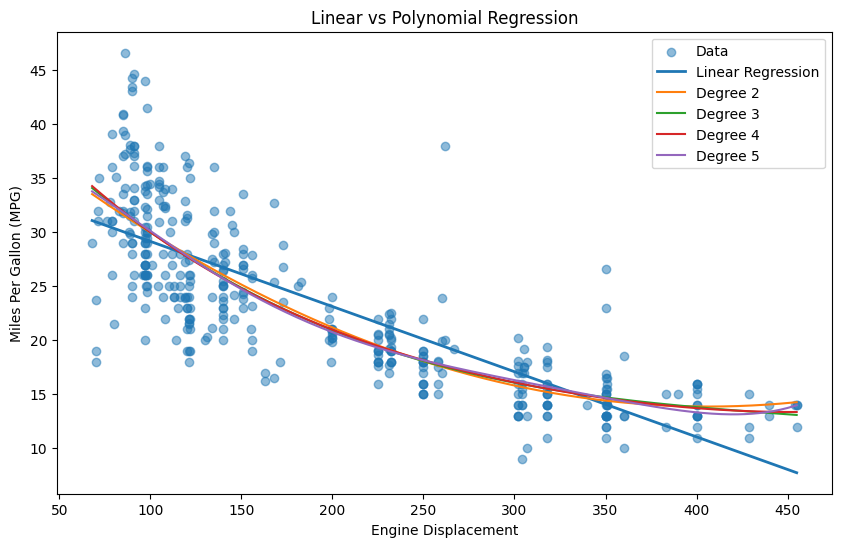

In [5]:
plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(X, y, alpha=0.5, label="Data")

# Smooth x values
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

# Linear Regression Line
linear_model.fit(X, y)
plt.plot(
    X_plot,
    linear_model.predict(X_plot),
    label="Linear Regression",
    linewidth=2
)

# Polynomial Fits
for degree in degrees:

    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    model.fit(X, y)

    plt.plot(
        X_plot,
        model.predict(X_plot),
        label=f"Degree {degree}"
    )

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()